In [1]:
%%writefile normal.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 2) return 1;
    long long n = std::atoll(argv[1]);
    int m = std::atoll(argv[2]);

    std::vector<int> arr(n, 1);
    volatile long long sum = 0; 

    for(int j = 0; j < m; ++j){
        for (long long i = 0; i < n; ++i) {
            sum += arr[i];
        }
    }
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    std::cout << time.count() << std::endl;

    return 0;
}

Overwriting normal.cpp


In [2]:
%%writefile random.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <numeric>
#include <random>
#include <algorithm>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 2) return 1;
    long long n = std::atoll(argv[1]);
    int m = std::atoll(argv[2]);

    std::vector<int> arr(n, 1);
    std::vector<int> indices(n);
    std::iota(indices.begin(), indices.end(), 0);

    std::random_device rd;
    std::mt19937 gen(rd());
    std::shuffle(indices.begin(), indices.end(), gen);

    volatile long long sum = 0;

    auto start = std::chrono::high_resolution_clock::now();

    for(int j = 0; j < m; ++j){
        for (long long i = 0; i < n; ++i) {
            sum += arr[indices[i]];
        }
    }
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    std::cout << time.count() << std::endl;

    return 0;
}

Overwriting random.cpp


Compiling C++ codes...
Compilation finished! Starting measurements...

Finished for N = 64
Finished for N = 128
Finished for N = 256
Finished for N = 512
Finished for N = 1024
Finished for N = 2048
Finished for N = 4096
Finished for N = 8192
Finished for N = 16384
Finished for N = 32768
Finished for N = 65536
Finished for N = 131072
Finished for N = 262144
Finished for N = 524288
Finished for N = 1048576
Finished for N = 2097152
Finished for N = 4194304
Finished for N = 8388608


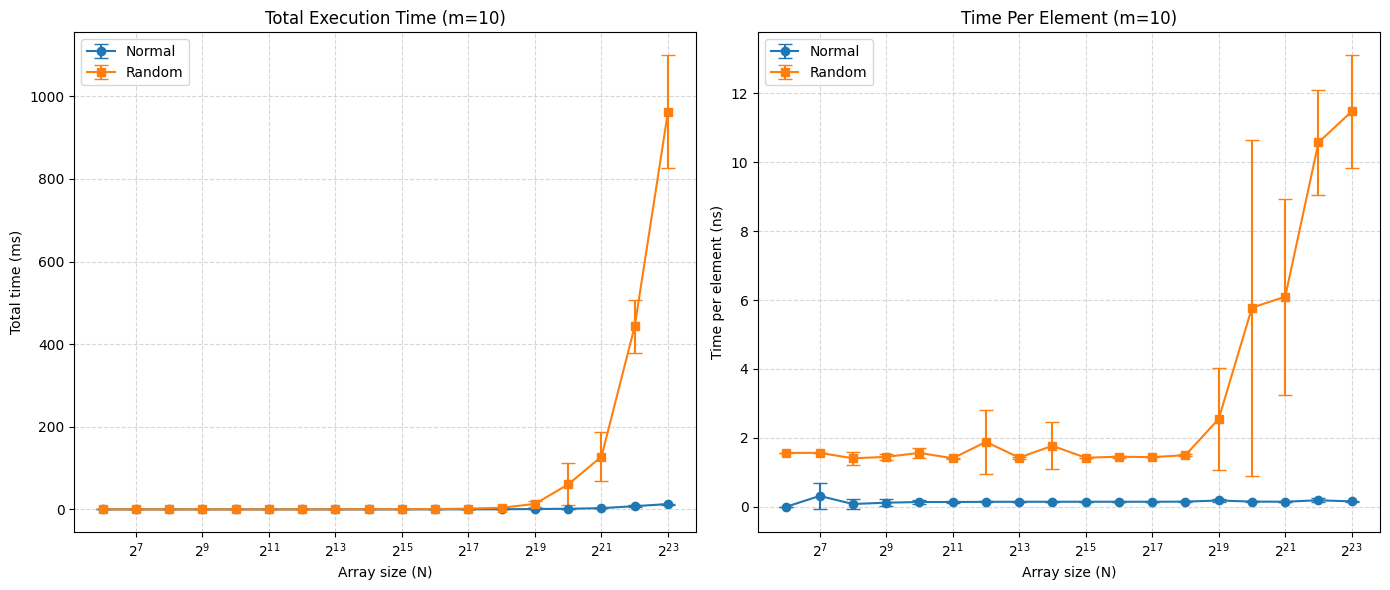

In [10]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os

print("Compiling C++ codes...")
bin_normal = "normal_bin.exe" if os.name == 'nt' else "./normal_bin"
bin_random = "random_bin.exe" if os.name == 'nt' else "./random_bin"

subprocess.run(["g++", "-O3", "normal.cpp", "-o", bin_normal.replace('./', '')])
subprocess.run(["g++", "-O3", "random.cpp", "-o", bin_random.replace('./', '')])
print("Compilation finished! Starting measurements...\n")

# --- SETTINGS ---
N_values = [2**i for i in range(6, 24)]
m_inner = 10      # How many times C++ loops through the array
M_python = 5      # How many times Python repeats everything for average and error calculation

# Lists for total time
res_norm_tot_mean, res_norm_tot_std = [], []
res_rand_tot_mean, res_rand_tot_std = [], []

# Lists for time per element
res_norm_elem_mean, res_norm_elem_std = [], []
res_rand_elem_mean, res_rand_elem_std = [], []

for n in N_values:
    times_norm_tot, times_norm_elem = [], []
    times_rand_tot, times_rand_elem = [], []

    for _ in range(M_python):
        # 1. Measurement for normal
        res_norm = subprocess.run([bin_normal, str(n), str(m_inner)], capture_output=True, text=True)
        tot_norm_ns = int(res_norm.stdout.strip())
        
        # Converting total time to milliseconds (ms) for better plot display
        times_norm_tot.append(tot_norm_ns / 1_000_000) 
        # Time per element: Total time / (number of elements * number of passes)
        times_norm_elem.append(tot_norm_ns / (n * m_inner))

        # 2. Measurement for random
        res_rand = subprocess.run([bin_random, str(n), str(m_inner)], capture_output=True, text=True)
        tot_rand_ns = int(res_rand.stdout.strip())
        
        times_rand_tot.append(tot_rand_ns / 1_000_000)
        times_rand_elem.append(tot_rand_ns / (n * m_inner))

    # Saving averages and standard deviations (Total Time)
    res_norm_tot_mean.append(np.mean(times_norm_tot))
    res_norm_tot_std.append(np.std(times_norm_tot))
    res_rand_tot_mean.append(np.mean(times_rand_tot))
    res_rand_tot_std.append(np.std(times_rand_tot))

    # Saving averages and standard deviations (Time Per Element)
    res_norm_elem_mean.append(np.mean(times_norm_elem))
    res_norm_elem_std.append(np.std(times_norm_elem))
    res_rand_elem_mean.append(np.mean(times_rand_elem))
    res_rand_elem_std.append(np.std(times_rand_elem))
    
    print(f"Finished for N = {n}")

# --- PLOTTING GRAPHS ---
# figsize=(14, 6) gives us a wide window for 2 side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# First plot (Left): Total time in milliseconds
ax1.errorbar(N_values, res_norm_tot_mean, yerr=res_norm_tot_std, label='Normal', fmt='-o', capsize=5)
ax1.errorbar(N_values, res_rand_tot_mean, yerr=res_rand_tot_std, label='Random', fmt='-s', capsize=5)
ax1.set_xscale('log', base=2)
ax1.set_xlabel('Array size (N)')
ax1.set_ylabel('Total time (ms)')
ax1.set_title(f'Total Execution Time (m={m_inner})')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Second plot (Right): Time per element in nanoseconds
ax2.errorbar(N_values, res_norm_elem_mean, yerr=res_norm_elem_std, label='Normal', fmt='-o', capsize=5)
ax2.errorbar(N_values, res_rand_elem_mean, yerr=res_rand_elem_std, label='Random', fmt='-s', capsize=5)
ax2.set_xscale('log', base=2)
ax2.set_xlabel('Array size (N)')
ax2.set_ylabel('Time per element (ns)')
ax2.set_title(f'Time Per Element (m={m_inner})')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
%%writefile stride_test.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 3) return 1;
    
    long long n = std::atoll(argv[1]);
    long long stride = std::atoll(argv[2]);

    std::vector<int> arr(n, 1);
    volatile long long sum = 0;

    long long accesses = n / stride;
    if (accesses == 0) return 0;

    auto start = std::chrono::high_resolution_clock::now();
    

    for (long long i = 0; i < n; i += stride) {
        sum += arr[i];
    }
    
    auto end = std::chrono::high_resolution_clock::now();
    
    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    
    std::cout << time.count() << " " << accesses << std::endl;

    return 0;
}

Writing stride_test.cpp


Finished for stride = 1
Finished for stride = 2
Finished for stride = 4
Finished for stride = 8
Finished for stride = 16
Finished for stride = 32
Finished for stride = 64
Finished for stride = 128
Finished for stride = 256
Finished for stride = 512
Finished for stride = 1024
Finished for stride = 2048


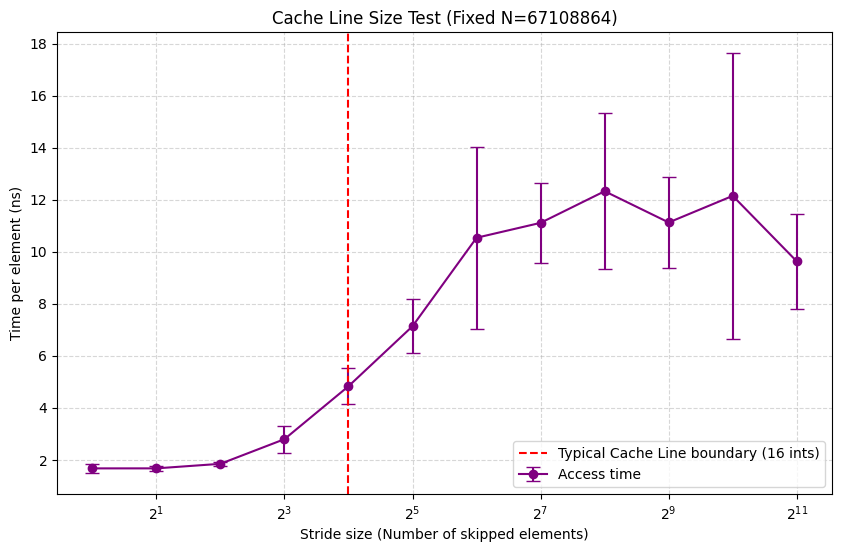

In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os

bin_stride = "stride_test.exe" if os.name == 'nt' else "./stride_test"
subprocess.run(["g++", "-O3", "stride_test.cpp", "-o", bin_stride.replace('./', '')])

N_fixed = 2**26 
strides = [2**i for i in range(0, 12)]
M = 10

results_mean = []
results_std = []

for stride in strides:
    times_per_access = []
    
    for _ in range(M):
        res = subprocess.run([bin_stride, str(N_fixed), str(stride)], capture_output=True, text=True)
        
        out_parts = res.stdout.strip().split()
        if len(out_parts) == 2:
            total_time = int(out_parts[0])
            accesses = int(out_parts[1])
            time_per_element = total_time / accesses
            times_per_access.append(time_per_element)
            
    results_mean.append(np.mean(times_per_access))
    results_std.append(np.std(times_per_access))
    
    print(f"Finished for stride = {stride}")

plt.figure(figsize=(10, 6))

plt.errorbar(strides, results_mean, yerr=results_std, 
             label='Access time', fmt='-o', color='purple', capsize=5)

plt.xscale('log', base=2)
plt.xlabel('Stride size (Number of skipped elements)')
plt.ylabel('Time per element (ns)')
plt.title(f'Cache Line Size Test (Fixed N={N_fixed})')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.axvline(x=16, color='red', linestyle='--', label='Typical Cache Line boundary (16 ints)')
plt.legend()

plt.show()

In [6]:
%%writefile pointer_chasing.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <numeric>
#include <random>
#include <algorithm>
#include <cstdlib>

int main(int argc, char* argv[]) {
    if (argc < 2) return 1;
    
    // N is the number of integers in our array
    long long n = std::atoll(argv[1]);
    
    // Fixed number of memory jumps so the test takes enough time
    long long accesses = 50000000; 

    std::vector<int> arr(n);
    std::vector<int> indices(n);
    std::iota(indices.begin(), indices.end(), 0);

    // Shuffle to create random jumps
    std::random_device rd;
    std::mt19937 gen(rd());
    std::shuffle(indices.begin(), indices.end(), gen);

    // Link the elements to form a single massive cyclic chain
    for (long long i = 0; i < n - 1; ++i) {
        arr[indices[i]] = indices[i + 1];
    }
    arr[indices[n - 1]] = indices[0]; // Close the loop

    // Warmup: load what we can into cache
    int curr = 0;
    for(long long i = 0; i < n; ++i) {
        curr = arr[curr];
    }

    auto start = std::chrono::high_resolution_clock::now();
    
    // THE CORE EXPERIMENT: purely chasing memory addresses
    for (long long i = 0; i < accesses; ++i) {
        curr = arr[curr];
    }
    
    auto end = std::chrono::high_resolution_clock::now();
    
    // Defeat compiler optimization by using 'curr' at the very end
    volatile int dummy = curr; 

    auto time = std::chrono::duration_cast<std::chrono::nanoseconds>(end - start);
    
    // Output total time and number of accesses
    std::cout << time.count() << " " << accesses << std::endl;

    return 0;
}

Writing pointer_chasing.cpp


Compiling C++ code...
Compilation finished! Starting precise measurements...

Tested Size:      4.0 KB | Time: 1.38 ns
Tested Size:      4.8 KB | Time: 1.33 ns
Tested Size:      5.7 KB | Time: 1.33 ns
Tested Size:      6.7 KB | Time: 2.43 ns
Tested Size:      8.0 KB | Time: 1.61 ns
Tested Size:      9.5 KB | Time: 1.51 ns
Tested Size:     11.3 KB | Time: 1.62 ns
Tested Size:     13.5 KB | Time: 1.62 ns
Tested Size:     16.0 KB | Time: 1.39 ns
Tested Size:     19.0 KB | Time: 1.49 ns
Tested Size:     22.6 KB | Time: 2.82 ns
Tested Size:     26.9 KB | Time: 1.48 ns
Tested Size:     32.0 KB | Time: 1.54 ns
Tested Size:     38.1 KB | Time: 2.75 ns
Tested Size:     45.3 KB | Time: 1.97 ns
Tested Size:     53.8 KB | Time: 2.43 ns
Tested Size:     64.0 KB | Time: 2.59 ns
Tested Size:     76.1 KB | Time: 3.25 ns
Tested Size:     90.5 KB | Time: 3.54 ns
Tested Size:    107.6 KB | Time: 3.02 ns
Tested Size:    128.0 KB | Time: 3.18 ns
Tested Size:    152.2 KB | Time: 3.95 ns
Tested Size:    181.

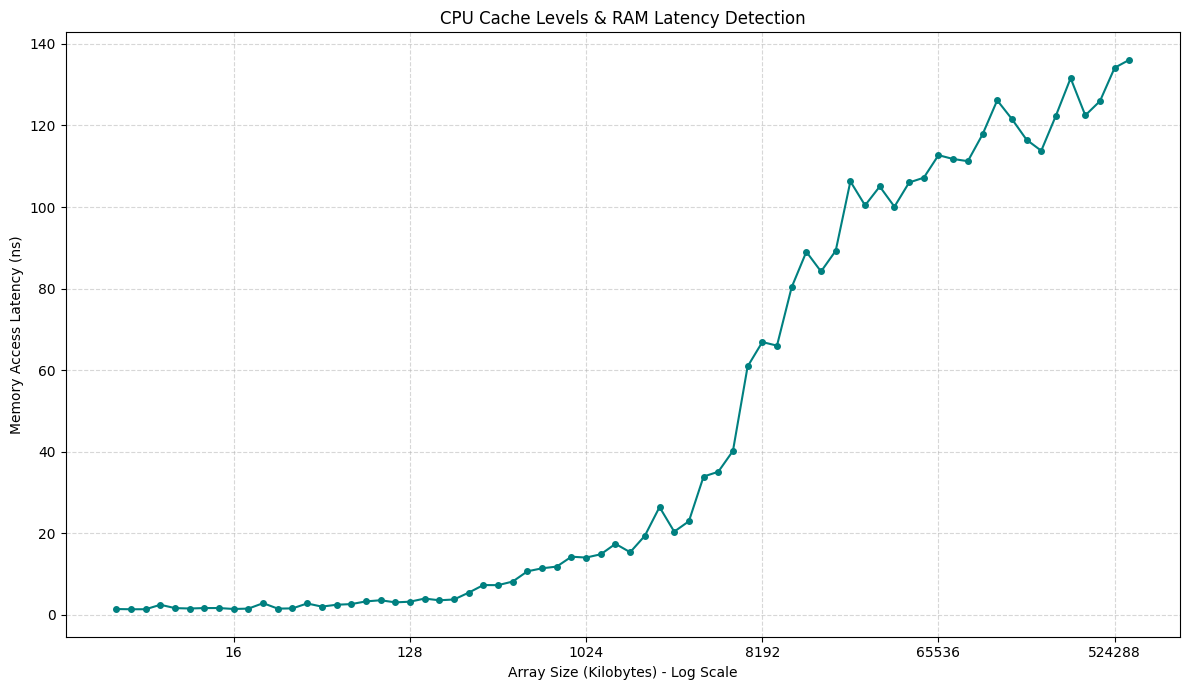

In [7]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os

print("Compiling C++ code...")
bin_chase = "pointer_chasing.exe" if os.name == 'nt' else "./pointer_chasing"
subprocess.run(["g++", "-O3", "pointer_chasing.cpp", "-o", bin_chase.replace('./', '')])
print("Compilation finished! Starting precise measurements...\n")

# Generate array sizes: We use fractional powers of 2 to get smooth, dense points on the graph.
# Range: from 2^10 (1024 ints = 4KB) to 2^27 (~134M ints = 536MB)
N_values = [int(2**(i / 4.0)) for i in range(40, 110)]

sizes_in_kb = []
times_per_access = []

for n in N_values:
    # Size in KB = (Number of ints * 4 bytes per int) / 1024
    size_kb = (n * 4) / 1024.0
    sizes_in_kb.append(size_kb)

    res = subprocess.run([bin_chase, str(n)], capture_output=True, text=True)
    out_parts = res.stdout.strip().split()
    
    if len(out_parts) == 2:
        total_time = int(out_parts[0])
        accesses = int(out_parts[1])
        times_per_access.append(total_time / accesses)
        
    print(f"Tested Size: {size_kb:8.1f} KB | Time: {times_per_access[-1]:.2f} ns")

# --- PLOTTING ---
plt.figure(figsize=(12, 7))

# Draw the line
plt.plot(sizes_in_kb, times_per_access, marker='o', markersize=4, linestyle='-', color='teal')

plt.xscale('log', base=2) # X-axis must be logarithmic to see the steps clearly
plt.xlabel('Array Size (Kilobytes) - Log Scale')
plt.ylabel('Memory Access Latency (ns)')
plt.title('CPU Cache Levels & RAM Latency Detection')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Optional formatting to make X-axis labels look like typical cache sizes (32, 64, 256, 1024, etc.)
from matplotlib.ticker import ScalarFormatter
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

In [ ]:
prave_granice = []
# Tipične granice u nanosekundama za ispadanje iz L1 (>5ns), iz L2 (>25ns) i iz L3 (>75ns)
pragovi_latencije = [5, 25, 75] 

for prag in pragovi_latencije:
    for i in range(len(times_per_access)):
        if times_per_access[i] > prag:
            # Spremi zadnju veličinu koja je bila ISPOD praga
            prave_granice.append(sizes_in_kb[i-1])
            break

print(f"Stvarne granice (preko pragova latencije): {prave_granice} KB")

Stvarne granice (Top 3 najveća skoka): [4096, 16384, 32768] KB


Compiling C++ code...
✅ Compilation finished! Starting targeted precise measurements...

Tested Size:     16.0 KB | Time: 1.33 ns
Tested Size:     64.0 KB | Time: 2.70 ns
Tested Size:    128.0 KB | Time: 2.94 ns
Tested Size:    256.0 KB | Time: 4.11 ns
Tested Size:    300.0 KB | Time: 6.95 ns
Tested Size:    350.0 KB | Time: 7.84 ns
Tested Size:    384.0 KB | Time: 7.46 ns
Tested Size:    400.0 KB | Time: 8.61 ns
Tested Size:    450.0 KB | Time: 9.15 ns
Tested Size:    512.0 KB | Time: 9.55 ns
Tested Size:    768.0 KB | Time: 12.34 ns
Tested Size:   1024.0 KB | Time: 14.60 ns
Tested Size:   1280.0 KB | Time: 15.76 ns
Tested Size:   1400.0 KB | Time: 15.88 ns
Tested Size:   1500.0 KB | Time: 17.72 ns
Tested Size:   1536.0 KB | Time: 17.12 ns
Tested Size:   1600.0 KB | Time: 17.17 ns
Tested Size:   1700.0 KB | Time: 20.22 ns
Tested Size:   2048.0 KB | Time: 18.82 ns
Tested Size:   4096.0 KB | Time: 29.61 ns
Tested Size:   6144.0 KB | Time: 51.45 ns
Tested Size:   8000.0 KB | Time: 52.29 

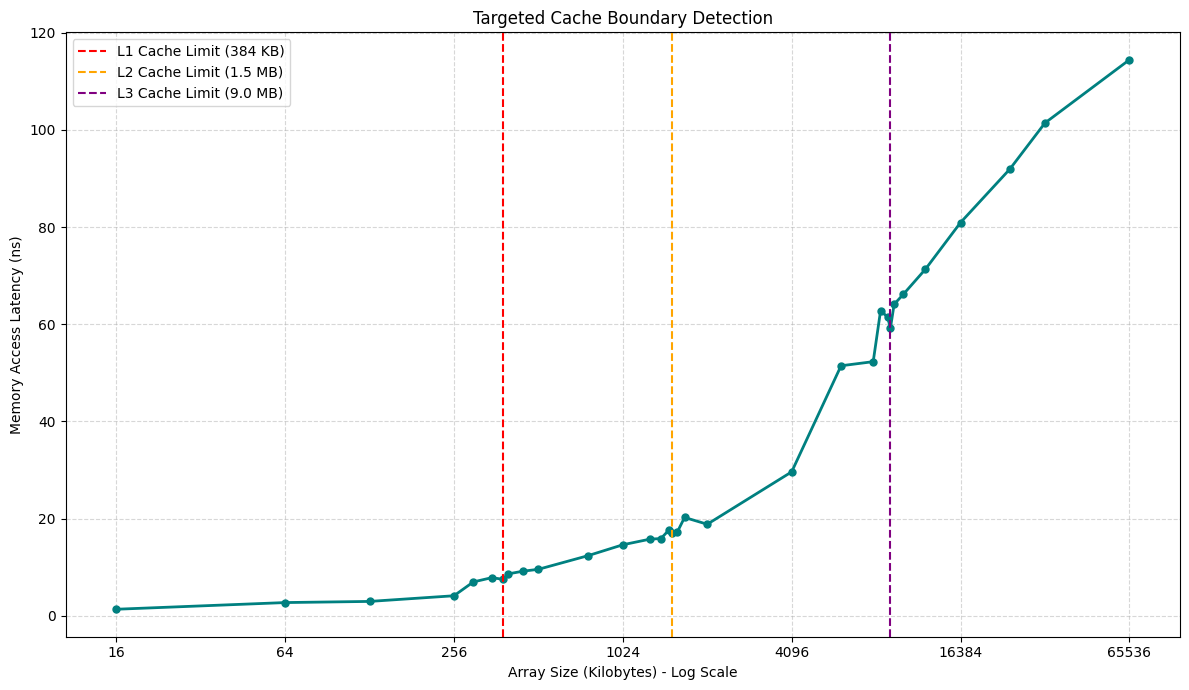

In [9]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

print("Compiling C++ code...")
bin_chase = "pointer_chasing.exe" if os.name == 'nt' else "./pointer_chasing"

compile_process = subprocess.run(
    ["g++", "-O3", "pointer_chasing.cpp", "-o", bin_chase.replace('./', '')],
    capture_output=True, text=True
)

if compile_process.returncode != 0:
    print("❌ COMPILATION ERROR!")
    print(compile_process.stderr)
    sys.exit(1)
else:
    print("✅ Compilation finished! Starting targeted precise measurements...\n")

# Targeted test sizes in KB. 
# Notice how we cluster the tests tightly around 384, 1536, and 9216.
target_kbs = [
    # Deep in L1
    16, 64, 128, 256,
    # L1 Boundary (384 KB)
    300, 350, 384, 400, 450, 512,
    # Deep in L2
    768, 1024, 1280,
    # L2 Boundary (1.5 MB = 1536 KB)
    1400, 1500, 1536, 1600, 1700, 2048,
    # Deep in L3
    4096, 6144, 8000,
    # L3 Boundary (9 MB = 9216 KB)
    8500, 9000, 9216, 9500, 10240, 12288,
    # Out in the RAM wilderness
    16384, 24576, 32768, 65536
]

target_kbs = sorted(list(set(target_kbs))) # Sort and remove any duplicates

sizes_in_kb = []
times_per_access = []

for kb in target_kbs:
    # Convert KB back to number of integers (N) for the C++ program
    # KB * 1024 = bytes. Divide by 4 (bytes per int) to get N.
    n = int((kb * 1024) / 4)
    
    res = subprocess.run([bin_chase, str(n)], capture_output=True, text=True)
    out_parts = res.stdout.strip().split()
    
    if len(out_parts) == 2:
        total_time = int(out_parts[0])
        accesses = int(out_parts[1])
        times_per_access.append(total_time / accesses)
        sizes_in_kb.append(kb)
        
    print(f"Tested Size: {kb:8.1f} KB | Time: {times_per_access[-1]:.2f} ns")

# --- PLOTTING ---
plt.figure(figsize=(12, 7))

plt.plot(sizes_in_kb, times_per_access, marker='o', markersize=5, linestyle='-', color='teal', linewidth=2)

# Dodavanje vertikalnih linija
plt.axvline(x=384, color='red', linestyle='--', label='L1 Cache Limit (384 KB)')
plt.axvline(x=1536, color='orange', linestyle='--', label='L2 Cache Limit (1.5 MB)')
plt.axvline(x=9216, color='purple', linestyle='--', label='L3 Cache Limit (9.0 MB)')

plt.xscale('log', base=2)
plt.xlabel('Array Size (Kilobytes) - Log Scale')
plt.ylabel('Memory Access Latency (ns)')
plt.title('Targeted Cache Boundary Detection')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

from matplotlib.ticker import ScalarFormatter
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

# --- NOVI DIO ZA ČIŠĆU X-OS ---
# Definiramo samo nekoliko glavnih točaka da graf diše
ciste_oznake = [16, 64, 256, 1024, 4096, 16384, 65536]
plt.xticks(ciste_oznake, ciste_oznake)

plt.tight_layout()
plt.show()